In [1]:
for (pkg in c("ggplot2", "dplyr", "tidyr", "patchwork")) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                pkg,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}
source("../../utils/r_themes.r")

In [2]:
data_split_data_path <- file.path("../data_splits/train_test_wells.parquet")
umap_coords_file_path <- file.path("../../3.generate_umap_and_PCA/results/UMAP/single-cell_profiles_CP_scDINO_all_timepoints_umap.parquet"
)
data_split_data <- arrow::read_parquet(data_split_data_path)
umap_coords <- arrow::read_parquet(umap_coords_file_path)
# merge the data split information with the UMAP coordinates
merged_data <- dplyr::left_join(umap_coords, data_split_data, by = c("Metadata_Well"))
merged_data$Metadata_Time <- as.numeric(merged_data$Metadata_Time) 
merged_data$Metadata_Time <- as.numeric(merged_data$Metadata_Time) * 30


In [3]:
height <- 14
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

# ---- 1. build a shared grid over the full UMAP space ----
n_bins <- 60  # lower than 100 - flood fill + per-group looping gets slow at very high res

x_range <- range(merged_data$UMAP_0, na.rm = TRUE)
y_range <- range(merged_data$UMAP_1, na.rm = TRUE)

x_breaks <- seq(x_range[1], x_range[2], length.out = n_bins + 1)
y_breaks <- seq(y_range[1], y_range[2], length.out = n_bins + 1)
bin_width_x <- diff(x_breaks)[1]
bin_width_y <- diff(y_breaks)[1]

merged_data <- merged_data |>
    dplyr::mutate(
        x_bin = cut(UMAP_0, breaks = x_breaks, include.lowest = TRUE, labels = FALSE),
        y_bin = cut(UMAP_1, breaks = y_breaks, include.lowest = TRUE, labels = FALSE)
    )


In [4]:

# ---- 2. flood-fill helper: fills interior holes of a logical occupancy matrix ----
fill_holes <- function(occ_mat) {
    nr <- nrow(occ_mat); nc <- ncol(occ_mat)
    total <- nr * nc
    outside <- matrix(FALSE, nr, nc)
    visited <- matrix(FALSE, nr, nc)
    queue <- integer(total)
    head <- 1L; tail <- 0L

    seed <- function(idx) {
        if (!occ_mat[idx] && !visited[idx]) {
            visited[idx] <<- TRUE
            tail <<- tail + 1L
            queue[tail] <<- idx
        }
    }
    for (r in c(1, nr)) for (c in seq_len(nc)) seed((c - 1) * nr + r)
    for (c in c(1, nc)) for (r in seq_len(nr)) seed((c - 1) * nr + r)

    while (head <= tail) {
        idx <- queue[head]; head <- head + 1L
        outside[idx] <- TRUE
        r <- ((idx - 1) %% nr) + 1L
        c <- ((idx - 1) %/% nr) + 1L
        if (r > 1)  { nidx <- idx - 1L; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
        if (r < nr) { nidx <- idx + 1L; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
        if (c > 1)  { nidx <- idx - nr; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
        if (c < nc) { nidx <- idx + nr; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
    }
    occ_mat | !outside
}

make_occ_matrix <- function(x_bin, y_bin, n_bins) {
    mat <- matrix(FALSE, n_bins, n_bins)
    idx <- unique(cbind(x_bin, y_bin))
    idx <- idx[stats::complete.cases(idx), , drop = FALSE]
    mat[cbind(idx[, 1], idx[, 2])] <- TRUE
    mat
}


In [5]:
# ---- 3. reference footprint: train's LAST timepoint, filled solid ----
train_last_time <- max(
    merged_data$Metadata_Time[merged_data$data_split == "train"],
    na.rm = TRUE
)

ref_xy <- merged_data |>
    dplyr::filter(data_split == "train", Metadata_Time == train_last_time)

reference_filled <- fill_holes(make_occ_matrix(ref_xy$x_bin, ref_xy$y_bin, n_bins))
reference_total_bins <- sum(reference_filled)  # fixed denominator, same for every group


In [6]:

# ---- 4. every (split, timepoint) footprint, filled solid, compared to reference ----
groups <- merged_data |> dplyr::distinct(data_split, Metadata_Time)

footprint_list <- vector("list", nrow(groups))
overlap_list <- vector("list", nrow(groups))  # NEW
for (i in seq_len(nrow(groups))) {
    ds <- groups$data_split[i]
    tp <- groups$Metadata_Time[i]
    sub <- merged_data |> dplyr::filter(data_split == ds, Metadata_Time == tp)
    current_filled <- fill_holes(make_occ_matrix(sub$x_bin, sub$y_bin, n_bins))

    df <- expand.grid(x_bin = seq_len(n_bins), y_bin = seq_len(n_bins))
    df$current <- as.vector(current_filled)
    df$reference <- as.vector(reference_filled)
    df$data_split <- ds
    df$Metadata_Time <- tp
    footprint_list[[i]] <- df

    # bin-count overlap stats for this group
    overlap_list[[i]] <- data.frame(
        data_split           = ds,
        Metadata_Time        = tp,
        overlap_bins         = sum(current_filled & reference_filled),
        current_total_bins   = sum(current_filled),
        reference_total_bins = reference_total_bins,
        union_bins           = sum(current_filled | reference_filled)
    )
}
footprint <- dplyr::bind_rows(footprint_list) |>
    dplyr::filter(current | reference) |>
    dplyr::mutate(
        footprint_type = dplyr::case_when(
            current & reference  ~ "Overlap with Reference",
            current & !reference ~ "Current Timepoint Only",
            !current & reference ~ "Reference Only"
        ),
        UMAP_0 = x_breaks[x_bin] + bin_width_x / 2,
        UMAP_1 = y_breaks[y_bin] + bin_width_y / 2
    )

# overlap summary table with three % metrics
overlap_summary <- dplyr::bind_rows(overlap_list) |>
    dplyr::mutate(
        pct_overlap_of_reference = 100 * overlap_bins / reference_total_bins,
        pct_overlap_of_current   = 100 * overlap_bins / current_total_bins,
        pct_overlap_jaccard      = 100 * overlap_bins / union_bins
    )

readr::write_csv(overlap_summary, "../figures/footprint_overlap_summary.csv")  # optional


In [7]:

# ---- 5. panel labels (refactored to a shared lookup, joined onto both data frames) ----
panel_label_lookup <- groups |>
    dplyr::arrange(data_split, Metadata_Time) |>
    dplyr::mutate(panel_label = paste0(stringr::str_to_title(data_split), " - ", Metadata_Time, " min"))

label_levels <- panel_label_lookup$panel_label

footprint <- footprint |>
    dplyr::left_join(panel_label_lookup, by = c("data_split", "Metadata_Time")) |>
    dplyr::mutate(panel_label = factor(panel_label, levels = label_levels))

overlap_summary <- overlap_summary |>  # same labels, for text annotation
    dplyr::left_join(panel_label_lookup, by = c("data_split", "Metadata_Time")) |>
    dplyr::mutate(panel_label = factor(panel_label, levels = label_levels))


In [8]:
head(footprint)

,x_bin,y_bin,current,reference,data_split,Metadata_Time,footprint_type,UMAP_0,UMAP_1,panel_label
,<int>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<fct>
1,46,2,FALSE,TRUE,train,0,Reference Only,4.311357,1.442901,Train - 0 min
2,47,3,FALSE,TRUE,train,0,Reference Only,4.431752,1.536858,Train - 0 min
3,48,3,FALSE,TRUE,train,0,Reference Only,4.552148,1.536858,Train - 0 min
4,49,3,FALSE,TRUE,train,0,Reference Only,4.672544,1.536858,Train - 0 min
5,50,3,FALSE,TRUE,train,0,Reference Only,4.792939,1.536858,Train - 0 min
6,51,3,FALSE,TRUE,train,0,Reference Only,4.913335,1.536858,Train - 0 min


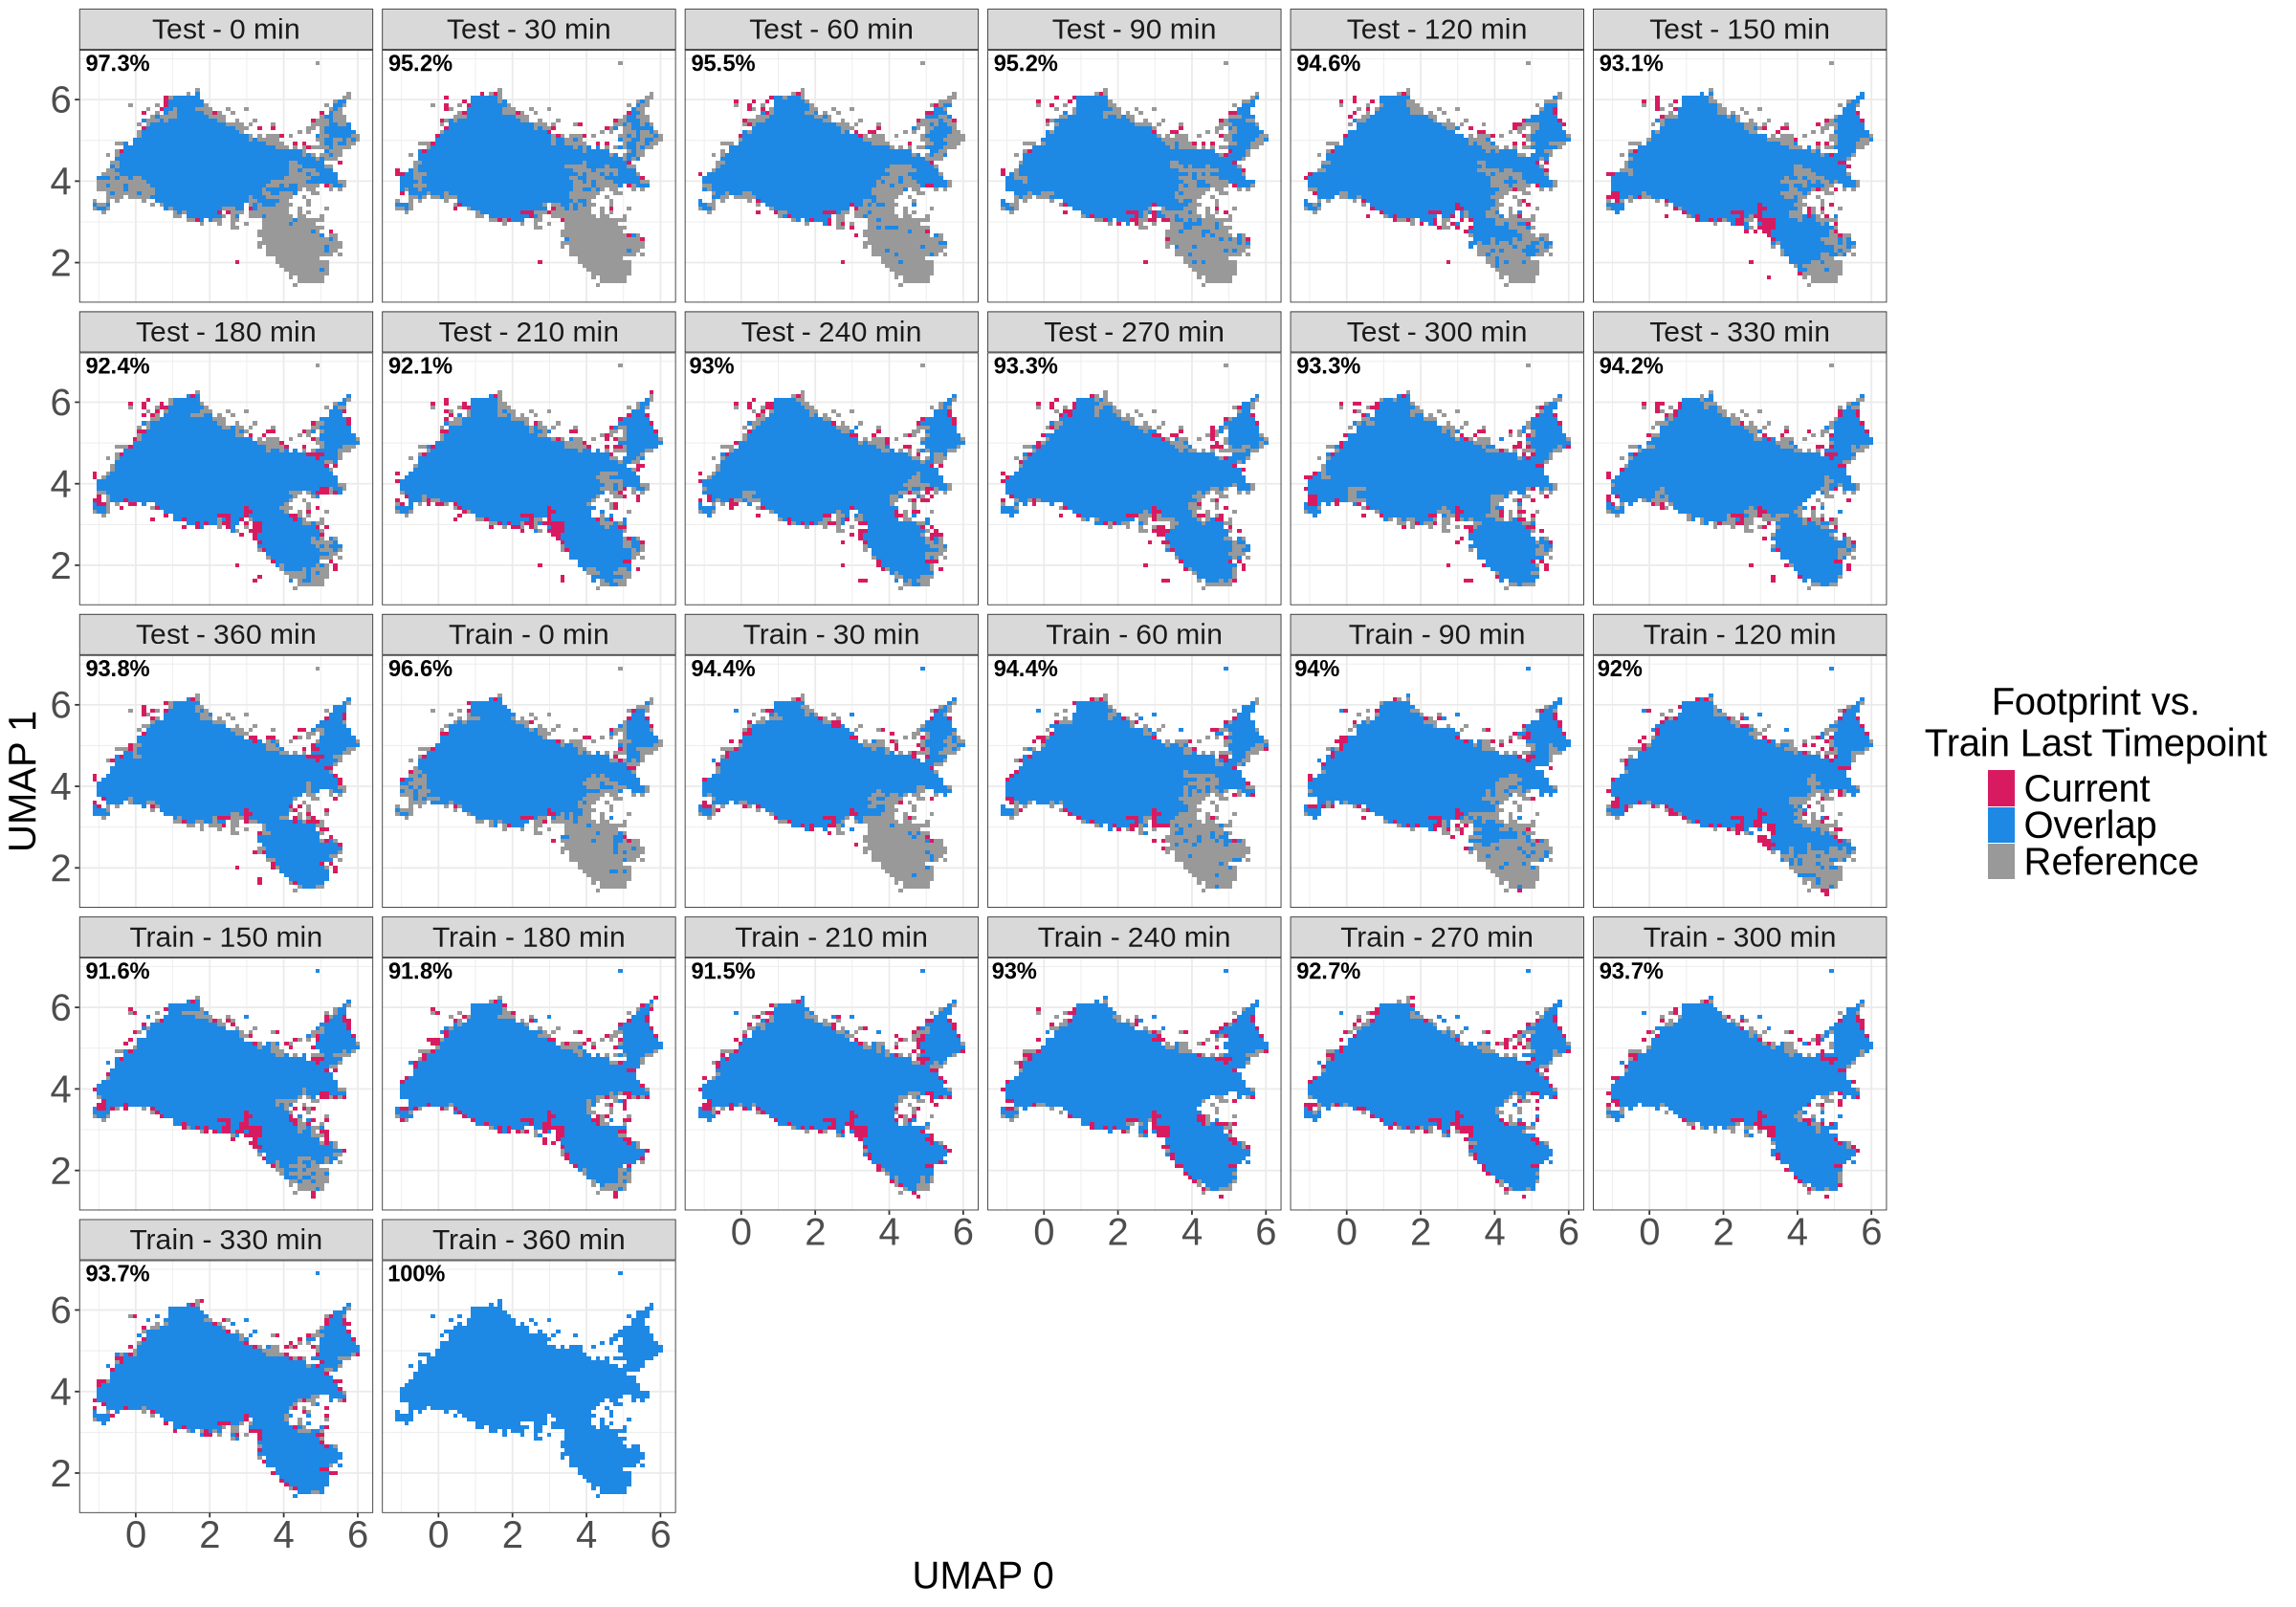

In [9]:
# replace text
footprint$footprint_type <- replace(
    footprint$footprint_type,
    footprint$footprint_type == "Reference Only", "Reference"
)
footprint$footprint_type <- replace(
    footprint$footprint_type,
    footprint$footprint_type == "Current Timepoint Only", "Current"
)
footprint$footprint_type <- replace(
    footprint$footprint_type,
    footprint$footprint_type == "Overlap with Reference", "Overlap"
)
# ---- 6. plot ----
footprint_plot <- (
    ggplot(footprint, aes(x = UMAP_0, y = UMAP_1, fill = footprint_type))
    + geom_tile(width = bin_width_x, height = bin_width_y)
    + scale_fill_manual(
        name = "Footprint vs.\nTrain Last Timepoint",
        values = c(
            "Reference"          = "#999999",
            "Current"  = "#D81B60",
            "Overlap"  = "#1E88E5"
        )
    )
    # % overlap-of-current annotation, one per facet
    + geom_text(
        data = overlap_summary,
        aes(x = -Inf, y = Inf, label = paste0(round(pct_overlap_of_current, 1), "%")),
        inherit.aes = FALSE,
        hjust = -0.1, vjust = 1.3, size = 5, fontface = "bold"
    )
    + facet_wrap(~panel_label)
    + theme_bw()
    + labs(x = "UMAP 0", y = "UMAP 1")
    + plot_themes
    # center the legend title
    + theme(
        legend.position = "right",  
        legend.title = element_text(hjust = 0.5),
        strip.text = element_text(size = 18)
    )
)
ggsave(footprint_plot, filename = "../figures/footprint_plot.png", width = width, height = height, units = "in", dpi = 600)
footprint_plot

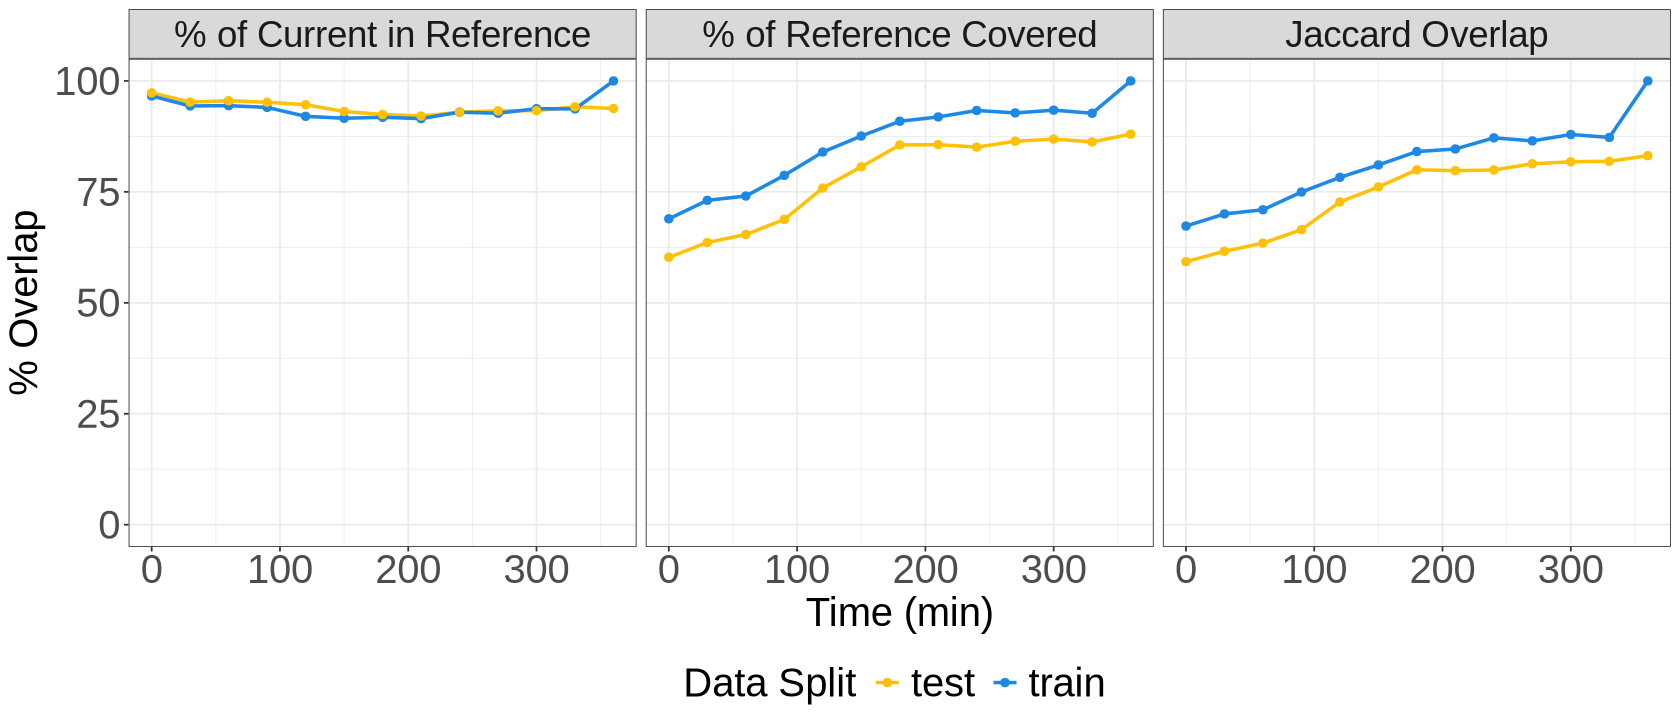

In [10]:

# ---- reshape to long format: one row per (split, time, metric) ----
overlap_long <- overlap_summary |>
    dplyr::select(data_split, Metadata_Time, 
                  pct_overlap_of_reference, pct_overlap_of_current, pct_overlap_jaccard) |>
    tidyr::pivot_longer(
        cols = starts_with("pct_overlap"),
        names_to = "metric",
        values_to = "pct_overlap"
    ) |>
    dplyr::mutate(
        metric = dplyr::recode(metric,
            "pct_overlap_of_reference" = "% of Reference Covered",
            "pct_overlap_of_current"   = "% of Current in Reference",
            "pct_overlap_jaccard"      = "Jaccard Overlap"
        )
    )

# ---- color palette for data_split (adjust to your actual split names) ----
split_color_palette <- c(
    "train" = "#1E88E5",
    "val"   = "#D81B60",
    "test"  = "#FFC107"
)

width <- 14
height <- 6
options(repr.plot.width = width, repr.plot.height = height)

overlap_over_time_plot <- (
    ggplot(overlap_long, aes(x = Metadata_Time, y = pct_overlap, color = data_split))
    + geom_line(linewidth = 1)
    + geom_point(size = 2)
    + facet_wrap(~metric, nrow = 1)
    + scale_color_manual(name = "Data Split", values = split_color_palette)
    + labs(
        x = "Time (min)",
        y = "% Overlap",
    )
    + ylim(0, 100)
    + theme_bw()
    + theme(
        axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
        axis.title.x = element_text(size = 16),
        axis.title.y = element_text(size = 16),
        axis.text.y = element_text(size = 14),
        plot.title = element_text(size = 16, hjust = 0.5),
        strip.text = element_text(size = 14),
        legend.title = element_text(size = 14),
        legend.text = element_text(size = 12)
    )
    + plot_themes
)
ggsave(overlap_over_time_plot, filename = "../figures/overlap_over_time_plot.png", 
       width = width, height = height, units = "in", dpi = 600)
overlap_over_time_plot

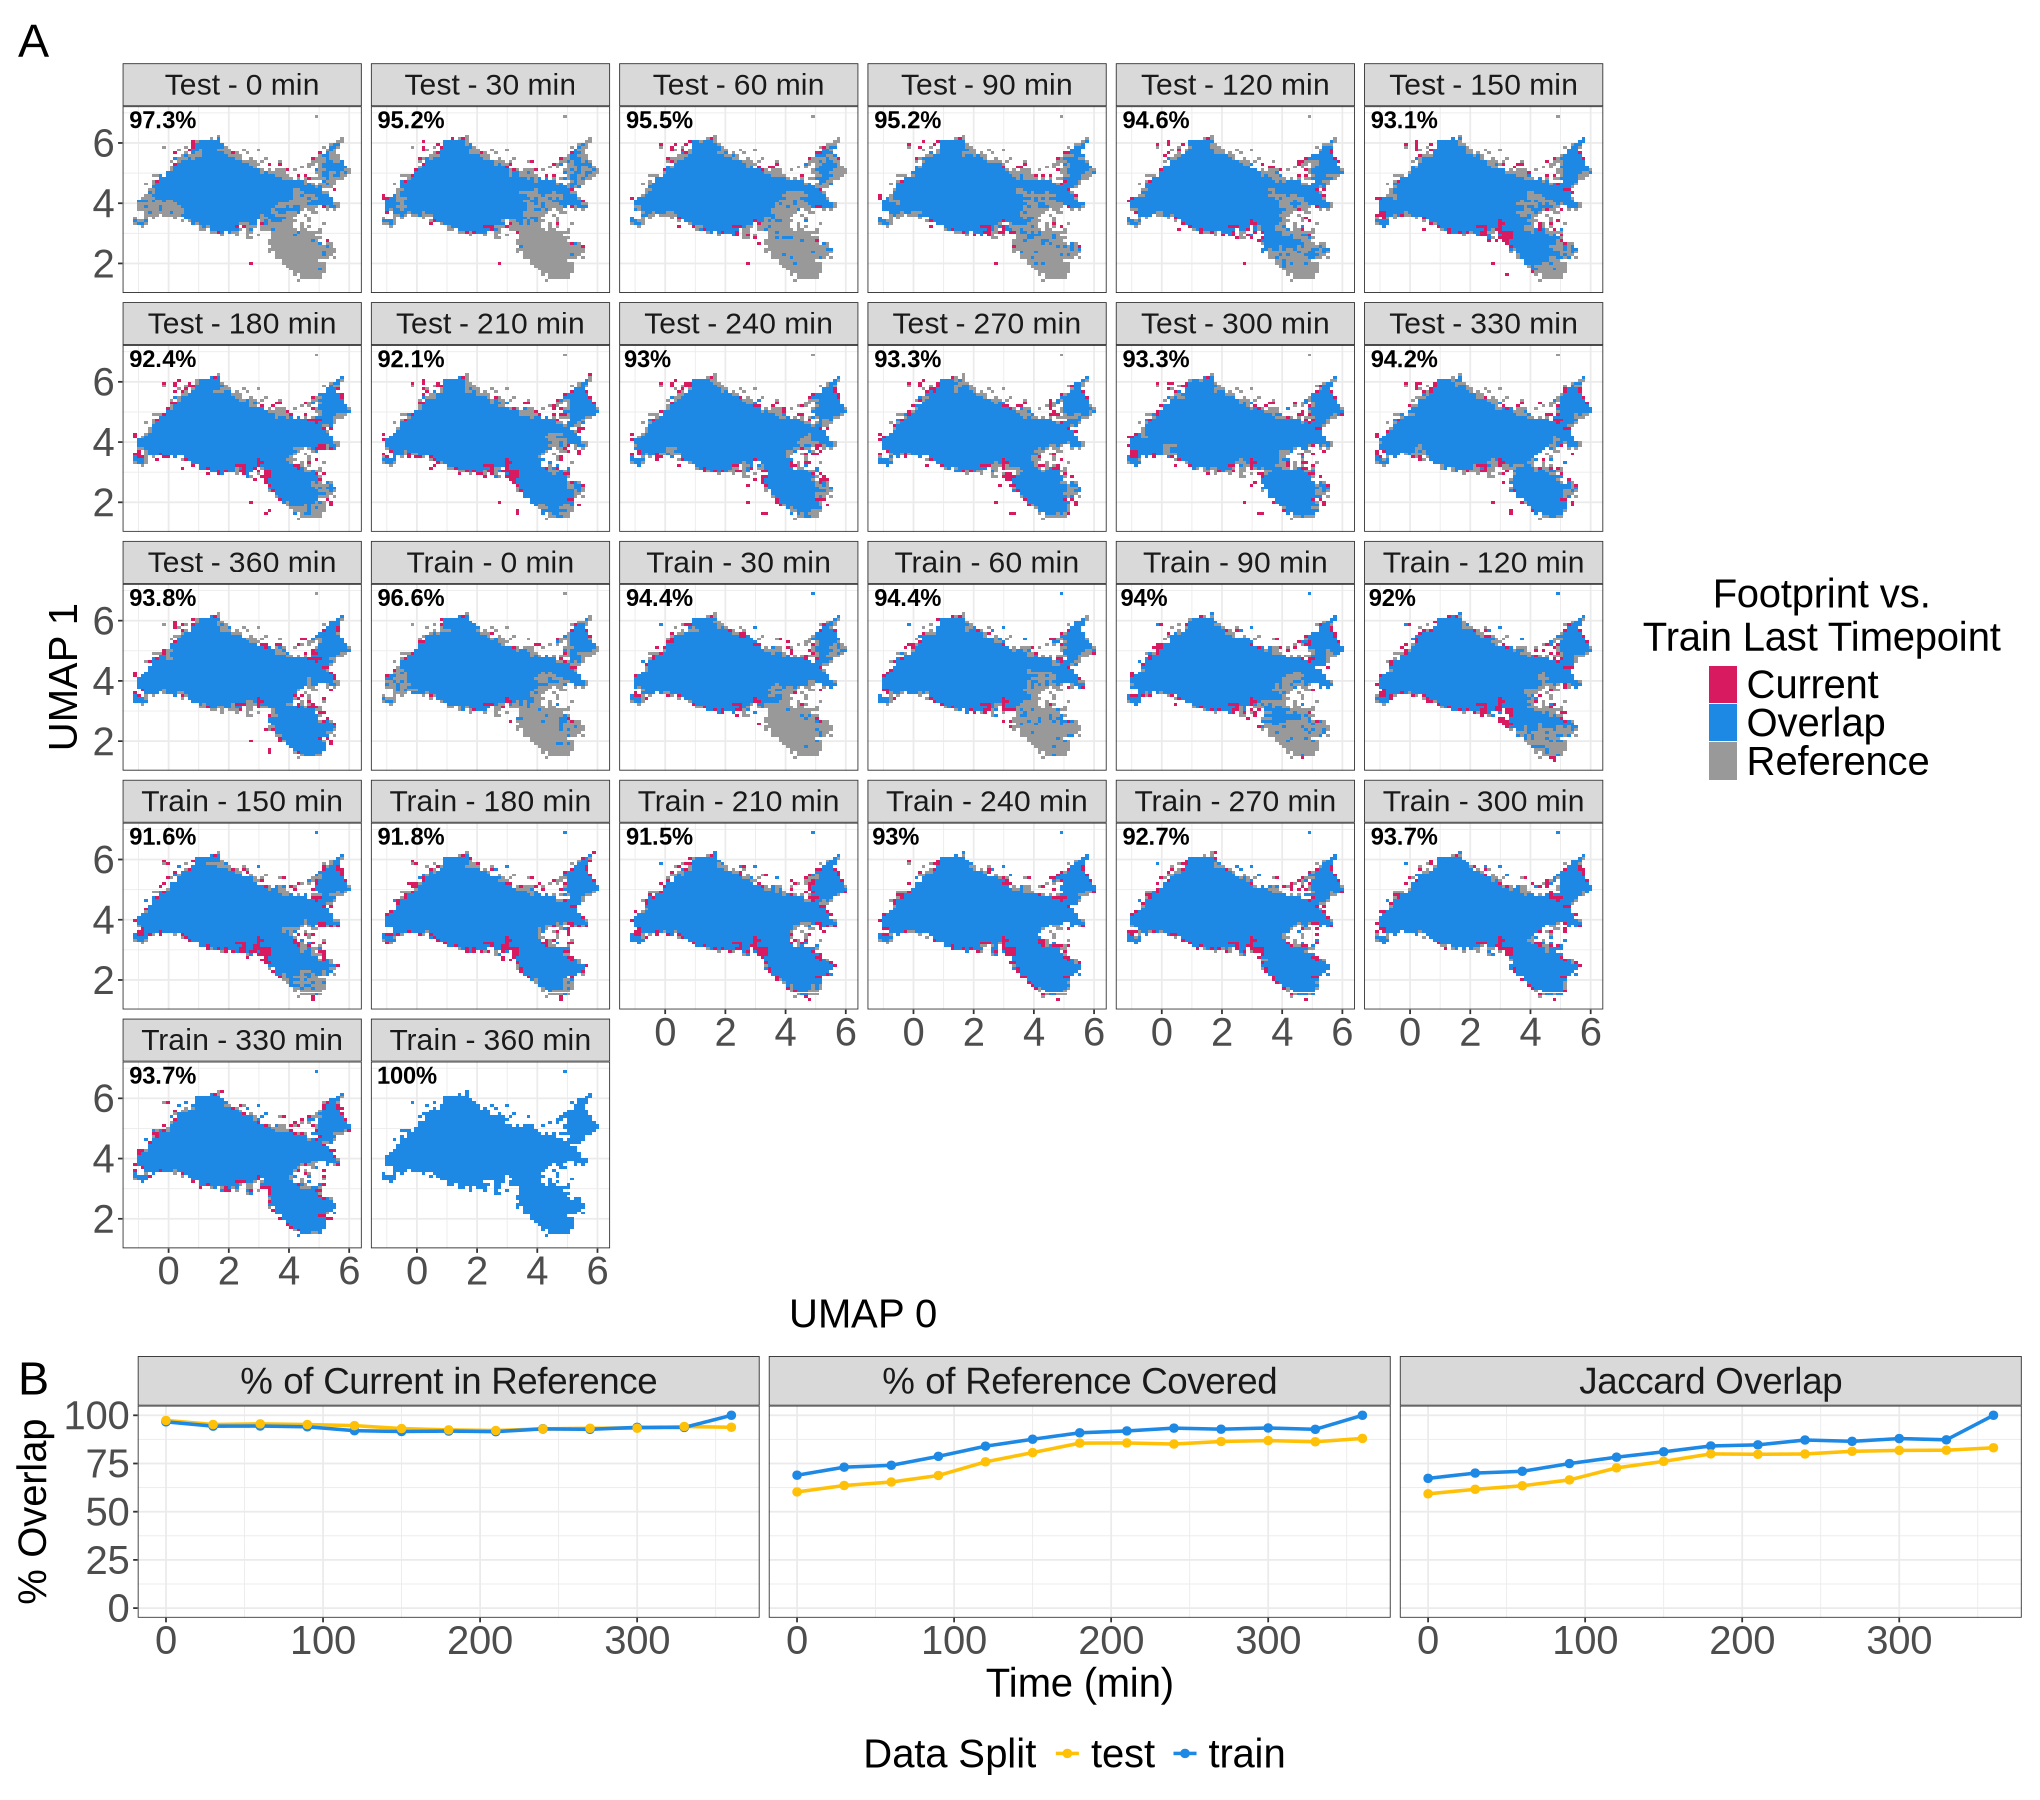

In [11]:
width <- 17
height <- 15
options(repr.plot.width=width, repr.plot.height=height)
layout <- "
AA
BB
"

final_plot <- (
    footprint_plot
    + wrap_elements(full = overlap_over_time_plot)
        + plot_layout(
        design = layout,
        heights = c(3, 1)
        )
    + plot_annotation(tag_levels = 'A') & theme(plot.tag = element_text(size = 28))

)
ggsave(final_plot, filename = "../figures/final_plot.png", width = width, height = height, units = "in", dpi = 600)
final_plot